# 0.9 — Exposure-Adjusted Region Growth

Follow-up to [`0.7_region_activity_gaps.ipynb`](0.7_region_activity_gaps.ipynb) and [`0.5_by_region_analysis.ipynb`](0.5_by_region_analysis.ipynb). Those notebooks established that 19 of 23 `Order Region`s go dark for months at a time and rotate on/off in cohorts — so every region-level *level* comparison so far (profit $, margin %, rank) has been a snapshot, not a trend.

**The question here**: restricted to the months a region actually had orders, is its own business growing, shrinking, or flat? And where a region gets more than one active window, does comparing those windows to each other (instead of to the zero months in between) surface a real regional trend — or does "growth" still turn out to be an artifact of *when* a region happened to be switched on, shared by everything else switched on at the same time?

Uses the same Oct-2017 cutoff as `0.1`–`0.8` (order-composition artifact) and the same margin convention (`profit = Order Profit Per Order`, `revenue = Order Item Total`, matching the dataset's own profit-ratio field per `0.2`).

## 1. Load & prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd(x, pos=None):
    if abs(x) >= 1000:
        return f"${x:,.0f}"
    return f"${x:,.1f}"

USD_FMT = mticker.FuncFormatter(usd)
DATA_DIR = '.'

In [2]:
df_full = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df_full['order date (DateOrders)'] = pd.to_datetime(df_full['order date (DateOrders)'])
df_full['month'] = df_full['order date (DateOrders)'].dt.to_period('M')

df = df_full[df_full['order date (DateOrders)'] < '2017-10-01'].copy()  # exclude Nov-2017+ order-composition artifact (0.1)
print(f"excluded {len(df_full) - len(df):,} rows from Oct 2017 onward ({(len(df_full)-len(df))/len(df_full)*100:.1f}% of {len(df_full):,})")
print(f"{df.shape[0]:,} order lines across {df['Order Region'].nunique()} regions, {df['order date (DateOrders)'].min().date()} -> {df['order date (DateOrders)'].max().date()}")

excluded 8,557 rows from Oct 2017 onward (4.7% of 180,519)
171,962 order lines across 23 regions, 2015-01-01 -> 2017-09-30


## 2. Which regions can a growth question even be asked of?

A region needs **two separate active windows** before "growth" means anything — otherwise there's nothing to compare its own business to except a gap where it was switched off, which `0.7` already showed isn't demand. First, find each region's contiguous active blocks (runs of consecutive months with >=1 order) in the pre-cutoff data.

In [3]:
def blocks_for(region, frame):
    sub = frame[frame['Order Region'] == region]
    months = sorted(sub['month'].unique())
    if not months:
        return []
    blks = []
    start = prev = months[0]
    for m in months[1:]:
        if (m - prev).n == 1:
            prev = m
        else:
            blks.append((start, prev))
            start = prev = m
    blks.append((start, prev))
    return blks

rows = []
for region in df['Order Region'].unique():
    sub = df[df['Order Region'] == region]
    for bi, (s, e) in enumerate(blocks_for(region, df), start=1):
        bsub = sub[(sub['month'] >= s) & (sub['month'] <= e)]
        n_months = (e - s).n + 1
        rev = bsub['Order Item Total'].sum()
        prof = bsub['Order Profit Per Order'].sum()
        n = bsub.shape[0]
        rows.append(dict(
            region=region, block=bi, start=str(s), end=str(e), n_months=n_months,
            rev_per_month=rev / n_months, profit_per_month=prof / n_months,
            orders_per_month=n / n_months, margin_pct=prof / rev * 100 if rev else np.nan,
        ))

blocks = pd.DataFrame(rows)
n_blocks_per_region = blocks.groupby('region')['block'].max()
print(f"{(n_blocks_per_region == 1).sum()} of {len(n_blocks_per_region)} regions have exactly ONE active window pre-cutoff -- growth cannot be measured for these at all.")
print(f"{(n_blocks_per_region >= 2).sum()} regions have 2+ windows to compare.")
blocks.sort_values(['region', 'block'])

15 of 23 regions have exactly ONE active window pre-cutoff -- growth cannot be measured for these at all.
8 regions have 2+ windows to compare.


,region,block,start,end,n_months,rev_per_month,profit_per_month,orders_per_month,margin_pct
28,Canada,1,2016-08,2017-01,6,28042.903615,3983.451660,159.833333,14.204847
19,Caribbean,1,2015-01,2015-05,5,149152.027658,16552.913955,842.600000,11.098015
20,Caribbean,2,2017-01,2017-06,6,122651.424654,14843.511708,684.166667,12.102193
9,Central Africa,1,2016-08,2017-01,6,48818.760527,5574.544993,279.500000,11.418858
17,Central America,1,2015-01,2015-05,5,494910.759429,58209.902052,2791.400000,11.761697
18,Central America,2,2017-01,2017-06,6,436549.319836,54215.343399,2397.333333,12.419065
31,Central Asia,1,2016-08,2017-01,6,16325.615152,2174.213342,92.166667,13.317803
23,East Africa,1,2016-08,2017-01,6,56342.385649,7194.621654,308.666667,12.769466
27,East of USA,1,2016-04,2016-08,5,246391.026779,31252.660039,1383.000000,12.684171
4,Eastern Asia,1,2015-10,2016-03,6,172919.876981,18877.320103,981.166667,10.916802


**15 of 23 regions** get exactly one active window in the pre-cutoff data and never appear a second time within it: the 4 USCA splits, Canada, all 5 Africa regions, Central Asia, West Asia, Eastern Europe — plus Oceania and Southeast Asia, whose only other burst of orders falls in Nov 2017-Jan 2018, inside the excluded order-composition-artifact window, so it's invisible to a clean comparison. For all 15, "is this region growing" isn't a question the data can answer, full stop — there's only one data point.

The other **8 regions** get switched on more than once pre-cutoff. But some "second windows" turn out to be a trickle of stray orders rather than a real second block of business — flag anything averaging under 100 orders/month as **noise-floor**, separately from genuine active windows.

In [4]:
blocks['tier'] = np.where(blocks['orders_per_month'] < 100, 'noise-floor (<100 orders/mo)', 'substantial')
display_cols = ['region', 'block', 'start', 'end', 'n_months', 'orders_per_month', 'rev_per_month', 'profit_per_month', 'margin_pct', 'tier']
pd.set_option('display.float_format', lambda x: f"{x:,.1f}")
blocks[display_cols].sort_values(['region', 'block'])

,region,block,start,end,n_months,orders_per_month,rev_per_month,profit_per_month,margin_pct,tier
28,Canada,1,2016-08,2017-01,6,159.8,"28,042.9","3,983.5",14.2,substantial
19,Caribbean,1,2015-01,2015-05,5,842.6,"149,152.0","16,552.9",11.1,substantial
20,Caribbean,2,2017-01,2017-06,6,684.2,"122,651.4","14,843.5",12.1,substantial
9,Central Africa,1,2016-08,2017-01,6,279.5,"48,818.8","5,574.5",11.4,substantial
17,Central America,1,2015-01,2015-05,5,"2,791.4","494,910.8","58,209.9",11.8,substantial
18,Central America,2,2017-01,2017-06,6,"2,397.3","436,549.3","54,215.3",12.4,substantial
31,Central Asia,1,2016-08,2017-01,6,92.2,"16,325.6","2,174.2",13.3,noise-floor (<100 orders/mo)
23,East Africa,1,2016-08,2017-01,6,308.7,"56,342.4","7,194.6",12.8,substantial
27,East of USA,1,2016-04,2016-08,5,"1,383.0","246,391.0","31,252.7",12.7,substantial
4,Eastern Asia,1,2015-10,2016-03,6,981.2,"172,919.9","18,877.3",10.9,substantial


Three regions (Western Europe, Northern Europe, Southern Europe) get a *middle* window between their two real blocks that's barely alive — 27-32 orders/month, ~1% of their normal volume, and it lands exactly inside the Aug 2016-Jan 2017 window where the 9-region single-block cohort is at full strength. Reads as leakage from that cohort's region assignment, not a second real Europe season, so it's excluded from the growth comparison below. Eastern Asia's second window (15 orders/month, briefly net-negative) gets the same treatment.

That leaves **7 regions with two genuinely substantial windows to compare**: the 3 LATAM regions (Caribbean, Central America, South America), the 3 Europe regions (using blocks 1 and 3, skipping the noise middle), and South Asia.

## 3. Before comparing windows: do blocks ramp, regardless of *when* they fall?

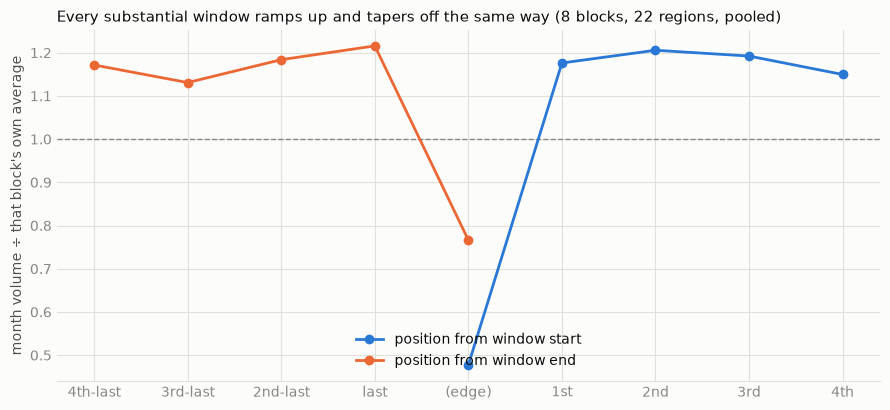

First month of a window runs at 48% of that window's own average.
Last month of a window runs at 77% of that window's own average.
Months 2-4 into a window run at 119% of average.


In [5]:
curves = []
for region in df['Order Region'].unique():
    sub = df[df['Order Region'] == region]
    for (s, e) in blocks_for(region, df):
        n_months = (e - s).n + 1
        if n_months < 4:
            continue
        bsub = sub[(sub['month'] >= s) & (sub['month'] <= e)]
        monthly = bsub.groupby('month').size().reindex(pd.period_range(s, e, freq='M'), fill_value=0)
        if monthly.mean() < 100:
            continue
        for i, v in enumerate(monthly.values):
            curves.append(dict(region=region, block=f"{s}-{e}", month_in_block=i, months_from_end=(n_months - 1) - i,
                                norm=v / monthly.mean()))

curve_df = pd.DataFrame(curves)
by_start = curve_df.groupby('month_in_block')['norm'].agg(['mean', 'count'])
by_end = curve_df.groupby('months_from_end')['norm'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(by_start.index[:5], by_start['mean'][:5], marker='o', color=BLUE, linewidth=2, label='position from window start')
ax.plot(-by_end.index[:5], by_end['mean'][:5], marker='o', color=ORANGE, linewidth=2, label='position from window end')
ax.axhline(1.0, color=INK_MUTED, linewidth=1, linestyle='--', zorder=1)
ax.set_xticks(range(-4, 5))
ax.set_xticklabels(['4th-last', '3rd-last', '2nd-last', 'last', '(edge)', '1st', '2nd', '3rd', '4th'])
ax.set_ylabel('month volume ÷ that block\'s own average')
ax.set_title(f'Every substantial window ramps up and tapers off the same way ({curve_df["block"].nunique()} blocks, {curve_df["region"].nunique()} regions, pooled)', loc='left', color=INK, fontsize=11)
ax.legend(frameon=False, loc='lower center')
style_axis(ax)
plt.tight_layout()
plt.show()

print("First month of a window runs at", f"{by_start['mean'].iloc[0]*100:.0f}%", "of that window's own average.")
print("Last month of a window runs at", f"{by_end['mean'].iloc[0]*100:.0f}%", "of that window's own average.")
print("Months 2-4 into a window run at", f"{by_start['mean'].iloc[1:4].mean()*100:.0f}%", "of average.")

Pooled across every substantial block from every cohort — 2015 launches and 2017 ones alike — the shape is identical: the **first month** of any window runs at only ~48% of that window's own average, the **last month** at ~77%, and the middle months hold steady 15-20% above average. This holds regardless of which calendar year or which region it is.

That's not what an organic regional launch or wind-down looks like — a real market doesn't ramp up for exactly one month everywhere it appears. It looks mechanical: a fade-in/fade-out on however a region gets "switched on" in the data generator. **Practical takeaway**: don't read anything into a region's first or last calendar month of activity — it's a partial month by construction, not a signal.

## 4. Block-to-block change, for the 7 regions where it's answerable

In [6]:
COHORT = {
    'Caribbean': 'LATAM', 'Central America': 'LATAM', 'South America': 'LATAM',
    'Western Europe': 'Europe', 'Northern Europe': 'Europe', 'Southern Europe': 'Europe',
    'South Asia': 'Pacific-Asia',
}
COHORT_COLOR = {'LATAM': NEG, 'Europe': BLUE, 'Pacific-Asia': ORANGE}

sub_blocks = blocks[(blocks['tier'] == 'substantial') & (blocks['region'].isin(COHORT))].copy()
# Europe: keep blocks 1 and 3 only (2 is the noise-floor one, already excluded by the tier filter above)
first = sub_blocks.sort_values('block').groupby('region').first()
last = sub_blocks.sort_values('block').groupby('region').last()

chg = pd.DataFrame({
    'cohort': first.index.map(COHORT),
    'first_window': first['start'] + ' to ' + first['end'],
    'last_window': last['start'] + ' to ' + last['end'],
    'rev_per_month_chg_pct': (last['rev_per_month'] / first['rev_per_month'] - 1) * 100,
    'profit_per_month_chg_pct': (last['profit_per_month'] / first['profit_per_month'] - 1) * 100,
    'margin_pp_chg': last['margin_pct'] - first['margin_pct'],
}).sort_values(['cohort', 'rev_per_month_chg_pct'], ascending=[True, False])
chg

,cohort,first_window,last_window,rev_per_month_chg_pct,profit_per_month_chg_pct,margin_pp_chg
region,,,,,,
Southern Europe,Europe,2015-05 to 2015-10,2017-06 to 2017-09,17.1,-4.6,-2.5
Western Europe,Europe,2015-05 to 2015-10,2017-06 to 2017-09,16.9,25.0,0.8
Northern Europe,Europe,2015-05 to 2015-10,2017-06 to 2017-09,13.7,10.4,-0.3
Central America,LATAM,2015-01 to 2015-05,2017-01 to 2017-06,-11.8,-6.9,0.7
South America,LATAM,2015-01 to 2015-05,2017-01 to 2017-06,-17.6,-17.1,0.1
Caribbean,LATAM,2015-01 to 2015-05,2017-01 to 2017-06,-17.8,-10.3,1.0
South Asia,Pacific-Asia,2015-10 to 2016-03,2016-08 to 2017-01,-71.9,-65.5,2.5


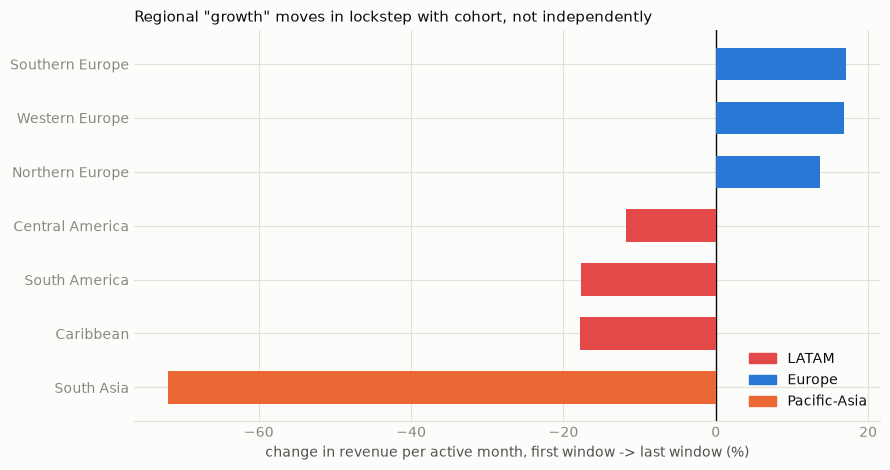

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_order = chg.sort_values('rev_per_month_chg_pct')
y = np.arange(len(plot_order))
colors = [COHORT_COLOR[c] for c in plot_order['cohort']]
ax.barh(y, plot_order['rev_per_month_chg_pct'], color=colors, zorder=3, height=0.6)
ax.axvline(0, color=INK, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_order.index)
ax.set_xlabel('change in revenue per active month, first window -> last window (%)')
ax.set_title('Regional "growth" moves in lockstep with cohort, not independently', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True, y_grid=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COHORT_COLOR[c], label=c) for c in ['LATAM', 'Europe', 'Pacific-Asia']],
          frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

Every region moves with its cohort, not against it:

- **All 3 LATAM regions decline** by a similar amount (-11.8% to -17.6% revenue/active-month) from their Jan-May 2015 window to their Jan-Jun 2017 window, with margin flat-to-slightly-better.
- **All 3 Europe regions grow** by a similar amount (+13.7% to +17.1% revenue/active-month) from their May-Oct 2015 window to their Jun-Sep 2017 window. Profit doesn't follow as cleanly — Western Europe's profit/month grows faster than revenue (+25.0%), while Southern Europe's margin compresses 2.5pp enough to make its profit/month fall (-4.6%) despite growing revenue.
- **South Asia is the one region with no cohort sibling to check against pre-cutoff**, and it shows the largest single move in the dataset: -71.9% revenue/active-month between its two windows. Its cohort partner Eastern Asia shows the same direction (collapsing toward the noise floor, excluded above), so even this outlier is corroborated in direction, just not in a clean same-scale sibling.

In every single case, there is zero example of one region in a cohort growing while a same-cohort, same-calendar-window sibling shrinks.

## 5. So is any of this a real regional trend?

If Central America, Caribbean and South America were three independently-run markets, there's no reason a Latin America slowdown and a Western Europe expansion should both land as a ~15% move, shared almost exactly by every region that happens to share a calendar window. The pattern that survives exposure-adjustment isn't "region X is winning, region Y is losing" — it's **"whichever regions were switched on during 2017's windows look different from whichever regions were switched on during 2015's windows, in the same direction, by about the same amount, no matter which specific regions they are."**

That's consistent with a single time-varying parameter in how this dataset was generated (order size or volume drifting across calendar time) applied uniformly to whatever regions happen to be active — not with 7 different regional businesses independently growing or shrinking. Combined with the universal ramp/taper shape in §3, the honest answer to "is this region growing within its own window" is: **not in a way that can be attributed to the region.** Any of these 7 point estimates could be quoted as "Region X grew/shrank N%" and it would be technically true of the two windows in the file — but not defensible as evidence about that region's actual trajectory.

## Takeaways — for the room

- **Nearly two-thirds of order regions (15 of 23) get exactly one clean active window and no second one to compare it to** — for these, a growth question isn't just unanswered, it's unanswerable. Don't let a single 5-6 month burst get read as this region's "current run rate."
- **A region's first and last active month is a partial month by construction.** Pooled across every substantial window in the dataset, the first month runs at ~48% of that window's own average and the last at ~77%, regardless of region or calendar year — trim these before quoting a region's monthly pace.
- **Only 7 of 23 regions have two comparable windows at all**, and even there, the direction and size of the change tracks the *cohort's* calendar window, not the region: all 3 LATAM regions decline together (-12% to -18%), all 3 Europe regions grow together (+14% to +17%), and the one uncorroborated region (South Asia, -71.9%) still moves the same direction as its nearest cohort sibling.
- **Bottom line for planning purposes: this dataset cannot currently support a claim that any specific region is genuinely growing or declining.** What exposure-adjustment recovers isn't a regional trend — it's confirmation that the apparent trend is shared by every region sharing a time window, which points at the data-generation process rather than at any region's underlying business. Pair with `0.7`'s region-rotation finding and `0.1`'s Nov-2017 order-composition finding: all three point the same direction — this dataset's generation process changes over calendar time, and region-level and period-level reads both inherit that.